### note
<br/>

### note name

In [1]:
# pip install ipynbname

import ipynbname
nb_name = ipynbname.name()
nb_path = ipynbname.path()

nb_name

'2Samples Classical_LSTM_P329 SEEDs_ini_2'

## Hyper parameters

In [2]:
SEED = 2
# SEEDs = range(10) # 0~9
L_RATE = 0.2 # 0.2
N_STEPS = 1000000
NUM_SEEDs = 50

In [3]:
from jax.config import config
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import pennylane as qml
from jax.example_libraries import optimizers
from jax.example_libraries import stax
from jax import value_and_grad
from jax import lax

import optax
# from functools import partial
import time
import matplotlib.pyplot as plt
import pickle


from SQGRU_j7x import SQGRU, qgru
from Classical_RNN import simple_rnn, gru, lstm, count_parameters

### force to use cpu

In [4]:
jax.config.update('jax_platform_name', 'cpu')

In [5]:
qml.version()

'0.31.1'

## Oscillations

In [6]:
def damped_shm(fre, damp):
    amp = 0.7
    num_data = 151
    x = jnp.array(range(num_data))
    y = jnp.sin(x*fre)*jnp.exp(x*damp)*amp

    return y

In [7]:
osc1 = damped_shm(0.4, 0)
osc2 = damped_shm(0.6, -0.02)

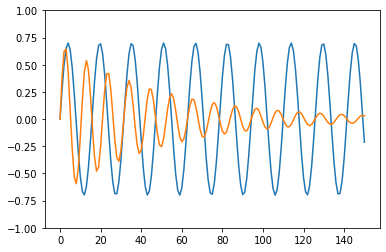

In [8]:
plt.plot(osc1)
plt.plot(osc2)
plt.ylim(-1,1)
plt.show()

In [9]:
oscillations = jnp.array([osc1,osc2])
true_data = jnp.expand_dims(oscillations, 2)
train_input = true_data[:,0:100,:]
train_target = true_data[:,1:101,:]

## Model
### Hyper parameters

In [10]:
# model parameters
OUT_DIM = 8

In [11]:
init_fun, qgru_rnn = stax.serial(lstm(OUT_DIM, sequence_out=True), stax.Dense(1))

In [12]:
key = jax.random.PRNGKey(SEED)
key1, key2 = jax.random.split(key, num=2)
_, params = init_fun(key1, jnp.shape(train_input))

In [13]:
count_parameters(params)

329

## Train

In [14]:
step_size = L_RATE
optimizer = optax.adam(step_size)
opt_state = optimizer.init(params)

In [15]:

@jax.jit
def loss_fn(params, xs, ys):
#     prediction = qgru_rnn(params, xs)[:,:,0:1]
    prediction = qgru_rnn(params, xs)
#     prediction = cls_predict(xs, 10, params)
    
    return jnp.mean((prediction - ys)**2) # the prediction shape


# def update(i_step, params, xs, ys, opt_state):
#     loss, grads = value_and_grad(loss_fn)(params, xs, ys)
#     updates, opt_state = optimizer.update(grads, opt_state)
#     params = optax.apply_updates(params, updates)
#     return params, opt_state, loss


In [16]:
minLoss = 1000
best_params = params
lossList = []
loc_params_list = []
reset_steps = []

In [17]:
def ck_lr(old_lr, new_lr):
    d_lr = old_lr - new_lr
    return d_lr >= 0 and d_lr/new_lr < 1e-2

### prediction

In [18]:
_, qgru_rnn2 = stax.serial(lstm(OUT_DIM, sequence_out=True), stax.Dense(1))

In [19]:
@jax.jit
def jit_rnn(params, inputs):
    return qgru_rnn2(params, inputs)

In [20]:
true1 = true_data.squeeze()[:,0:100]
true2 = true_data.squeeze()[:,100:]
xs = train_input

In [21]:
# for classical rnn to predict the trend
def cls_predict(inp, pred_length, params):
    ys = jit_rnn(params, inp)
    new_inp = inp
    for _ in range(pred_length-1):
        new_inp = jnp.concatenate([new_inp, ys[:,-1:]], axis=1)
        ys = jit_rnn(params, new_inp)
    return ys

### start

In [22]:
update_lr = True
lr_factor = 1
locLossList = [1000,1000,1000]
locLoss = 1000
loc_params = params



start = time.time()
for i in range(N_STEPS):
    
    if update_lr != 0:
        if update_lr < 0:
            params = loc_params
        else:
            locLossList = [1000,1000,1000]
            locLoss = 1000
            loc_params_list.append(loc_params)
            reset_steps.append(i)
            # reset parameters
            key1, key2 = jax.random.split(key2, num=2)
            _, params = init_fun(key1, jnp.shape(train_input))
            loc_params = params
            # stop when collect 3 local best parameters
            if len(loc_params_list) > NUM_SEEDs:
                break
        update_lr = 0
            
        # update learning rate
        optimizer = optax.adam(step_size)
        opt_state = optimizer.init(params)
        
        print('learning rate:', step_size)

        def update(i_step, params, xs, ys, opt_state):
            loss, grads = value_and_grad(loss_fn)(params, xs, ys)
            updates, opt_state = optimizer.update(grads, opt_state)
            params = optax.apply_updates(params, updates)
            return params, opt_state, loss
    
    pre_params = params
    params, opt_state, loss = update(i, params, train_input, train_target, opt_state)
    print('{}: {}   {} sec      '.format(i, loss, time.time()-start), end='\r')
    if loss < minLoss:
        best_params = pre_params
        minLoss = loss
    if loss < locLoss:
        loc_params = pre_params
        locLoss = loss
    if (i+1) % 100 == 0:
        # update learning rate?
        if loss > locLossList[0] and locLossList[1] > locLossList[0] and locLossList[2] > locLossList[0]:
            step_size /= 2
            update_lr = -1
        elif ck_lr(locLossList[2], loss) and ck_lr(locLossList[1], locLossList[2]) and ck_lr(locLossList[0], locLossList[1]):
            # reset
            step_size = L_RATE
            update_lr = 1
        locLossList[0] = locLossList[1]
        locLossList[1] = locLossList[2]
        locLossList[2] = loss
        
        
        lossList.append(loss)
        print('{}: {}   {} sec      '.format(i, loss, time.time()-start))

learning rate: 0.2
99: 0.00023893703290533375   2.0554141998291016 sec      
199: 0.0001780921740054151   3.0316481590270996 sec       
299: 0.00015560369536845697   3.9761648178100586 sec      
399: 0.00013887219929230071   4.904569387435913 sec       
499: 0.00012482857989235089   5.865292549133301 sec       
599: 0.00016586465630989187   6.837911605834961 sec       
699: 0.00010440786424156607   7.763075828552246 sec       
799: 0.00010847055722846081   8.679413318634033 sec       
899: 0.0003383696933282902   9.564819574356079 sec       
999: 7.909512681847606e-05   10.482765674591064 sec      
1099: 0.0002762673035018553   11.42096996307373 sec        
1199: 7.199121517346625e-05   12.382113456726074 sec       
1299: 0.03093301811235004   13.329549551010132 sec         
1399: 0.004967160589240928   14.195580959320068 sec       
1499: 0.0018922418350371252   15.156795024871826 sec      
learning rate: 0.1
1599: 0.00014787696934970895   16.092416048049927 sec      
1699: 0.000129931

26599: 0.0004808609939538963   285.5524272918701 sec        
26699: 3.8597711443462034e-05   286.64806628227234 sec      
26799: 3.593420158941155e-05   287.79296350479126 sec       
learning rate: 0.05
26899: 5.349493175629995e-05   288.896502494812 sec         
26999: 4.1418009234310855e-05   290.05149269104004 sec      
27099: 3.72615696951423e-05   291.2304804325104 sec         
learning rate: 0.025
27199: 3.684909744960791e-05   292.4235064983368 sec        
27299: 3.529541196781251e-05   293.6011486053467 sec        
27399: 3.458798265311128e-05   294.7712230682373 sec        
27499: 3.420371329035521e-05   295.8451008796692 sec        
27599: 3.3942250585509416e-05   296.94367027282715 sec      
27699: 3.4981969862700035e-05   298.08707189559937 sec      
27799: 3.37981598302421e-05   299.3323857784271 sec         
27899: 3.361059193116232e-05   300.493017911911 sec         
27999: 3.34766434886872e-05   301.6740131378174 sec         
28099: 3.337463319736533e-05   302.791711568

52899: 8.239577052511351e-05   585.3086311817169 sec       
52999: 3.832861623361811e-05   586.4392175674438 sec       
53099: 3.895529745387863e-05   587.588356256485 sec        
53199: 3.805156607493272e-05   588.6654443740845 sec       
53299: 0.0001273389075256312   589.811491727829 sec        
53399: 3.5670523366096604e-05   590.9344234466553 sec      
53499: 0.0003089740613363283   592.145589351654 sec        
53599: 3.5082437069447245e-05   593.3131098747253 sec      
53699: 0.00017016981672423448   594.4928841590881 sec      
53799: 3.4620628587208276e-05   595.6163873672485 sec      
53899: 3.466639685408253e-05   596.7498939037323 sec       
53999: 3.390083355485004e-05   597.9546666145325 sec       
54099: 3.4124194573205896e-05   599.0801599025726 sec      
54199: 3.500636380997632e-05   600.233068227768 sec        
54299: 3.425477598772808e-05   601.3800201416016 sec       
learning rate: 0.025
54399: 3.658512930095177e-05   602.4875783920288 sec       
learning rate: 0.01

79399: 0.00013395937169561624   908.5222840309143 sec      
79499: 0.00011381730280875672   909.7112307548523 sec      
79599: 0.005370284302825328   910.8360910415649 sec        
79699: 0.0002246161976962649   912.0128617286682 sec       
79799: 0.00014636088186895465   913.1089897155762 sec      
learning rate: 0.1
79899: 0.01369141432686439   914.2281451225281 sec        
79999: 0.0031585643838483004   915.2809791564941 sec      
80099: 0.0017647608430365115   916.3637118339539 sec      
learning rate: 0.05
80199: 0.000706947180515137   917.4245121479034 sec       
80299: 0.00026043649162819867   918.575953245163 sec       
80399: 0.00020451311251653604   919.6601662635803 sec      
80499: 0.00017639152321459835   920.8112590312958 sec      
80599: 0.000157760572446711   921.9371693134308 sec        
80699: 0.0001447562882933772   923.0651385784149 sec       
80799: 0.00013581598926466838   924.2099556922913 sec      
80899: 0.00012956194367908674   925.3858869075775 sec      
80999

105799: 3.4741721096082116e-05   1217.2528989315033 sec      
105899: 3.4831602893083214e-05   1218.3791363239288 sec      
105999: 3.751640854475555e-05   1219.5340757369995 sec       
learning rate: 0.0125
106099: 3.432531493860158e-05   1220.669627904892 sec        
106199: 3.4032896583125744e-05   1221.9140000343323 sec      
106299: 3.39048326630626e-05   1223.0356645584106 sec        
106399: 3.379835068654412e-05   1224.1974506378174 sec       
learning rate: 0.2
106499: 0.0002510857257790664   1225.3322286605835 sec       
106599: 0.00023283762386366218   1226.4417638778687 sec      
106699: 0.00021677490911742287   1227.5701215267181 sec      
106799: 0.00019761509662141234   1228.6969242095947 sec      
106899: 0.00018110894687578874   1229.874661207199 sec       
106999: 0.0001664055801261487   1231.0382294654846 sec       
107099: 0.07996186795400982   1232.1517627239227 sec         
107199: 0.0004564806129906705   1233.3052988052368 sec       
107299: 0.000323596742852318 

...

234499: 4.1247750558445805e-05   2568.729419231415 sec       
234599: 3.872176257541542e-05   2569.524229288101 sec        
234699: 4.540664827686885e-05   2570.282640695572 sec        
234799: 3.702726986529777e-05   2571.0298476219177 sec       
234899: 3.683681409848464e-05   2571.7606699466705 sec       
234999: 4.462876544316042e-05   2572.487283229828 sec        
235099: 4.5821076543848876e-05   2573.2085287570953 sec      
235199: 4.142962372617399e-05   2574.009891271591 sec        
learning rate: 0.025
235299: 4.305223727878069e-05   2574.7649431228638 sec       
235399: 3.7122053997059416e-05   2575.502875804901 sec       
235499: 3.608338510125275e-05   2576.2391498088837 sec       
235599: 3.618153861699855e-05   2576.9695789813995 sec       
235699: 3.530854987760764e-05   2577.694454431534 sec        
235799: 3.485714491122775e-05   2578.4236755371094 sec       
235899: 3.4503652010995445e-05   2579.1505620479584 sec      
235999: 3.421138621503526e-05   2579.891537427902

247399: 0.00036589625429200536   2664.823639154434 sec       
247499: 0.0001579996245860088   2665.5680482387543 sec       
247599: 0.0001274421219132061   2666.3037526607513 sec       
247699: 0.00011144682787661605   2667.0456280708313 sec      
247799: 0.00010232594702436604   2667.780195236206 sec       
247899: 9.639185864262872e-05   2668.5282781124115 sec       
247999: 9.188564598079675e-05   2669.2605278491974 sec      
248099: 8.821214693486238e-05   2670.001152038574 sec       
248199: 8.521595955768044e-05   2670.7333240509033 sec      
248299: 8.276293539879468e-05   2671.456220626831 sec       
248399: 8.068139820648766e-05   2672.208480358124 sec       
248499: 7.877538417995344e-05   2672.9302191734314 sec      
248599: 7.689380411514786e-05   2673.6738464832306 sec      
248699: 7.496540314864328e-05   2674.414093732834 sec       
248799: 7.295776432089947e-05   2675.1422865390778 sec      
248899: 7.085222115624178e-05   2675.8870599269867 sec      
248999: 6.86519090

273299: 0.0009693622753334574   2856.953622341156 sec       
273399: 0.00021426029428977988   2857.751118659973 sec       
learning rate: 0.05
273499: 0.0004370236354441646   2858.5351436138153 sec       
273599: 0.00022942289472689968   2859.467176437378 sec       
273699: 0.00014470348099446853   2860.24325633049 sec        
273799: 0.00011594341242592944   2860.9779286384583 sec      
273899: 0.00010874598120168426   2861.717084169388 sec       
273999: 0.00010498555521188422   2862.463542699814 sec       
274099: 0.00010122282975912518   2863.1831312179565 sec      
274199: 9.724840738505436e-05   2863.9039657115936 sec       
274299: 9.335424809574314e-05   2864.6226449012756 sec      
274399: 8.972635119010277e-05   2865.3513197898865 sec      
274499: 8.635742820673458e-05   2866.0746445655823 sec      
274599: 8.319686706746512e-05   2866.8031373023987 sec      
274699: 8.021899462336774e-05   2867.520472049713 sec       
274799: 7.741575060871828e-05   2868.2800619602203 sec  

299099: 4.343996183641395e-05   3048.3255541324615 sec       
299199: 4.243761674249267e-05   3049.048491716385 sec        
299299: 4.3286506886904587e-05   3049.7838077545166 sec      
299399: 3.919126018869469e-05   3050.531473636627 sec        
299499: 3.8010393040590576e-05   3051.307892560959 sec       
299599: 3.655699227128269e-05   3052.0403246879578 sec       
299699: 3.5599715661135255e-05   3052.7607192993164 sec      
299799: 3.456680405503401e-05   3053.487336874008 sec        
299899: 4.920811846484329e-05   3054.213812828064 sec        
299999: 3.378117185618116e-05   3054.9305939674377 sec       
300099: 3.3578571788475626e-05   3055.668571472168 sec       
300199: 3.364678213326655e-05   3056.411430120468 sec        
300299: 3.341759447556146e-05   3057.1354188919067 sec       
300399: 3.332925978931539e-05   3057.852816104889 sec        
300499: 3.4695779595379326e-05   3058.603190422058 sec       
300599: 3.329959223196853e-05   3059.3196341991425 sec       
300699: 

324899: 4.052540223458415e-05   3239.730524778366 sec        
324999: 0.0011825981889702895   3240.449238061905 sec        
325099: 0.0004611984083587396   3241.2035772800446 sec       
325199: 0.0003543971634763702   3241.9216458797455 sec       
learning rate: 0.0125
325299: 0.00023789780828155198   3242.6426796913147 sec      
325399: 0.00018878460559534197   3243.405060529709 sec       
325499: 0.00015655006908123402   3244.149202108383 sec       
325599: 0.000132158307171588   3244.8665330410004 sec        
325699: 0.00011526457443163916   3245.587312936783 sec       
325799: 0.00010402747549658163   3246.307782649994 sec       
325899: 9.609868917134488e-05   3247.0620374679565 sec       
325999: 8.988839091914556e-05   3247.8076174259186 sec      
326099: 8.466093965471663e-05   3248.541766643524 sec       
326199: 8.011419769008156e-05   3249.263444662094 sec       
326299: 7.611723566235121e-05   3250.0465438365936 sec      
326399: 7.25996087769568e-05   3250.7810587882996 se

In [23]:
minLoss

Array(3.30320743e-05, dtype=float64)

In [24]:
# Save
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'wb') as f:
    pickle.dump((lossList, minLoss, params, best_params, loc_params_list, reset_steps), f)

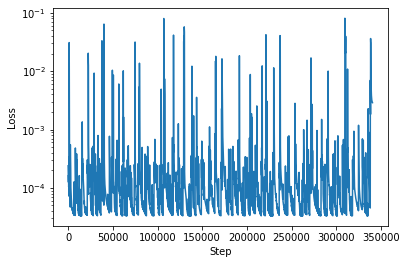

In [25]:
plt.plot([x*100 for x in range(len(lossList))], lossList)
plt.ylabel('Loss')
plt.xlabel('Step')
plt.yscale("log")
plt.show()

## Result

### best parameters

In [26]:
ys = cls_predict(xs, 50, best_params)

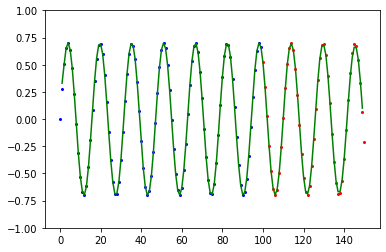

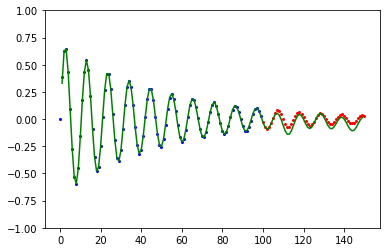

In [27]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

### final parameters

In [28]:
ys = cls_predict(xs, 50, params)

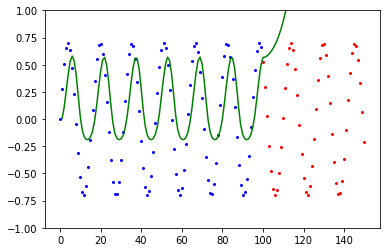

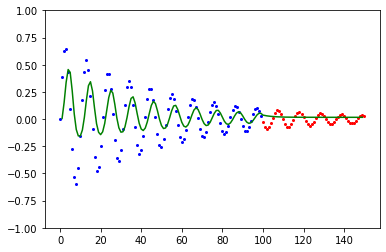

In [29]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

## Load & find the best parameters

In [22]:
# load
# Loss, minLoss, params, best_params, loc_params_list, reset_steps
with open(nb_name+'_state.pkl', 'rb') as f:
    lossList, minLoss, params, best_params, loc_params_list, reset_steps = pickle.load(f)

In [23]:
test_result = []
min_loss = 1000
k = 0
for i in reset_steps[1:]:
    k += 1
    j = int(i/100 -1)
    i_loss = lossList[j]
    i_params = loc_params_list[k]
    
    ys = cls_predict(xs, 50, i_params)
    
    t_loss = jnp.mean((true2[:,:-1]-ys[:,-50:,0])**2)
    test_result.append([i,i_loss,t_loss,i_params,ys])
    if t_loss < min_loss:
        min_loss = t_loss
        min_idx = k-1
        min_ys = ys
        
test_result[min_idx]

[229100,
 Array(3.30320743e-05, dtype=float64),
 Array(0.00082867, dtype=float64),
 [(Array([[ 0.92242527, -0.66634745,  0.68812167, -0.06765144, -0.68878123,
            0.86252312,  0.08333668, -0.24531499]], dtype=float64),
   Array([[ 0.33035259,  0.62161993,  0.09808078,  0.23006916, -0.61761959,
            0.41391272,  0.32927427, -0.52440031],
          [-0.28804632,  0.08205118, -0.11502266,  0.63457854,  0.09934006,
           -0.23560442,  0.40955935, -0.44854815],
          [ 0.3483743 , -0.59694112,  0.06437018, -0.26709308, -0.04277286,
           -0.1862579 ,  0.20038934, -0.34269031],
          [-0.5186936 , -0.65540886,  0.73756436,  0.68295556, -0.03092393,
           -0.05943296,  0.06627608,  0.10727284],
          [ 0.19591654, -0.0477361 , -0.09523344, -0.75126136,  0.43603524,
           -0.03642058, -0.35445791, -0.00785892],
          [-0.09205831, -0.21445974, -0.10664758, -0.72866315, -0.35643186,
           -0.29685091,  0.43863593, -0.21521554],
          [

In [24]:
# Save results
# [[i,i_loss,t_loss,i_params,ys]...]
with open(nb_name+'_test_result.pkl', 'wb') as f:
    pickle.dump(test_result, f)

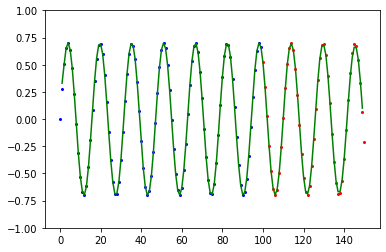

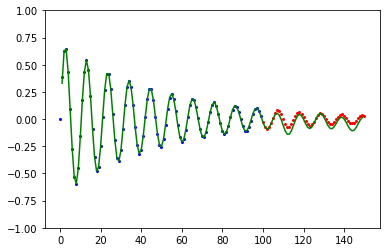

In [32]:
for idx in [0, 1]:
    plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
    plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
    plt.plot(jnp.array(range(len(min_ys[idx])))+1, min_ys[idx], c='g')
    plt.ylim(-1,1)
    plt.show()

best: [229100, Array(3.30320743e-05, dtype=float64), Array(0.00082867, dtype=float64)]
8100 3.368881576697736e-05 0.3582354571030162


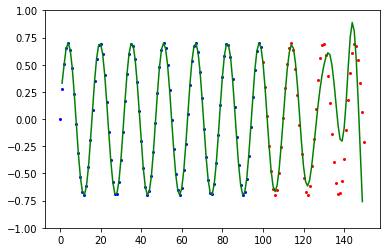

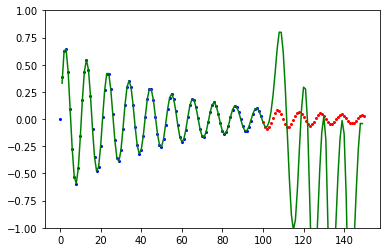

15300 3.321395371951562e-05 0.10653351046431539


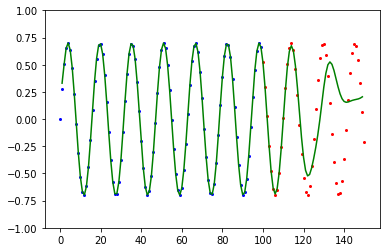

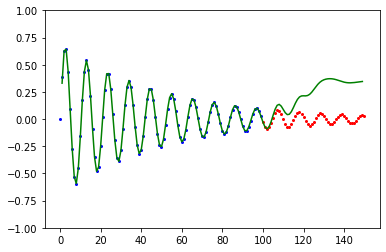

21500 3.3824751069018014e-05 0.03940562824830945


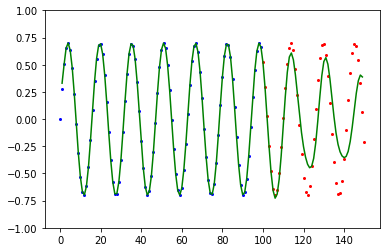

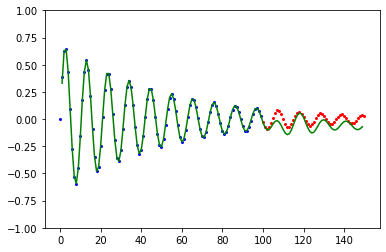

28100 3.337463319736533e-05 0.034901550068277304


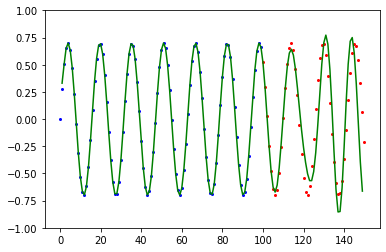

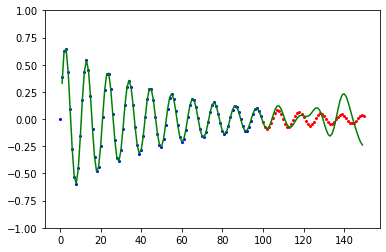

32900 3.326122472498424e-05 0.0794401336188122


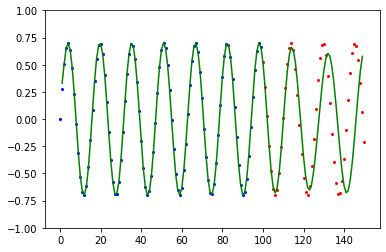

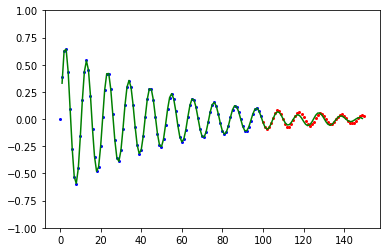

36800 3.3898680519197634e-05 0.06520300960366612


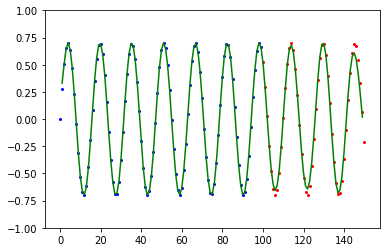

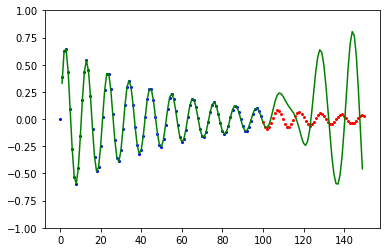

48600 3.879751391015945e-05 0.09856964830927409


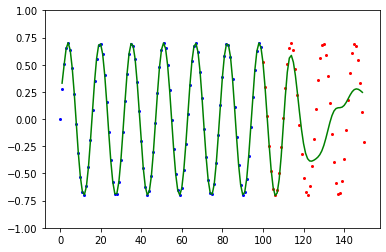

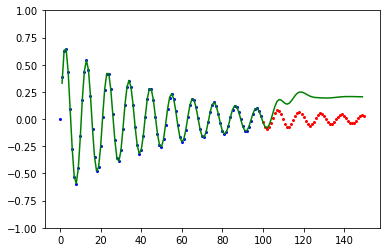

54800 3.355854027172161e-05 1.9925915981508617


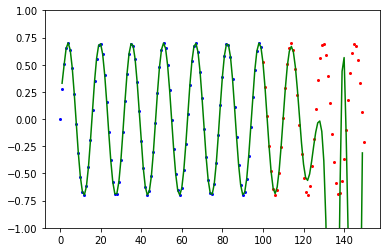

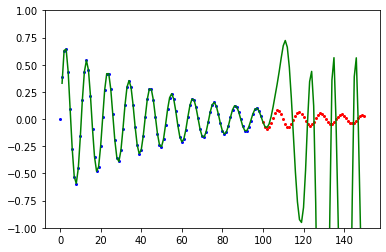

61200 3.3412946521343865e-05 0.12238209592652424


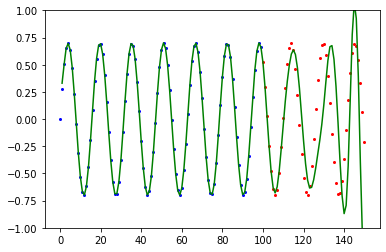

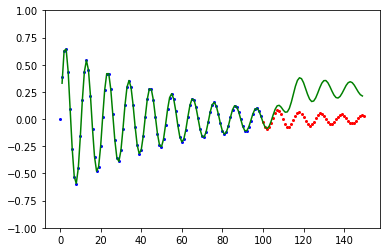

66200 3.3308785739013107e-05 0.04066204125212735


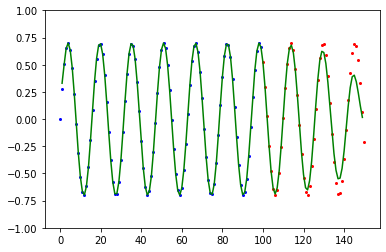

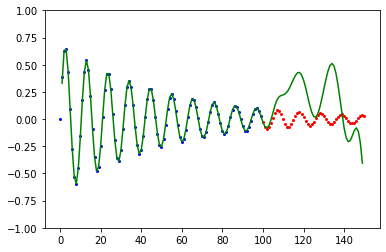

74000 3.353056930441809e-05 0.6438603471390539


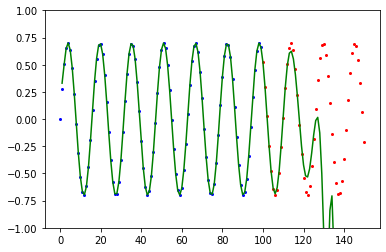

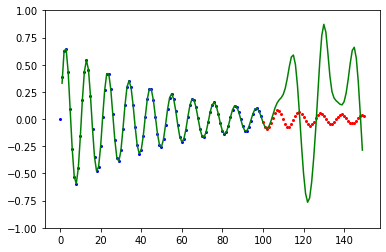

78700 3.422030825879379e-05 0.0929020257421289


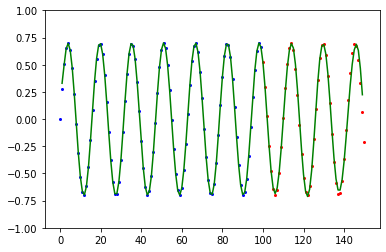

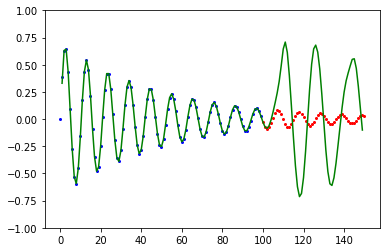

87700 3.332866094933852e-05 0.29895453426954294


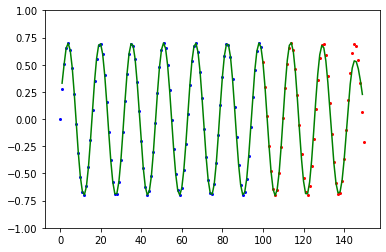

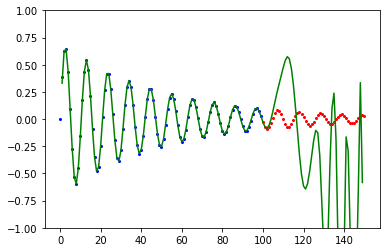

96100 3.326686040424265e-05 0.11678029979444027


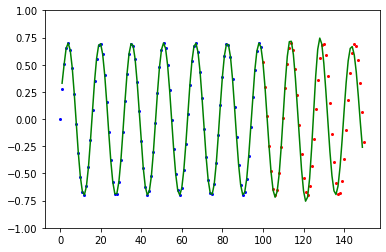

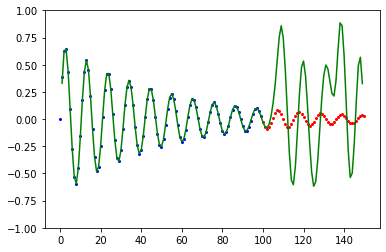

102300 3.373856017185351e-05 0.2841835048144601


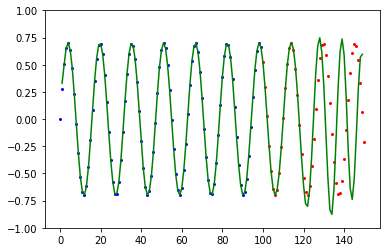

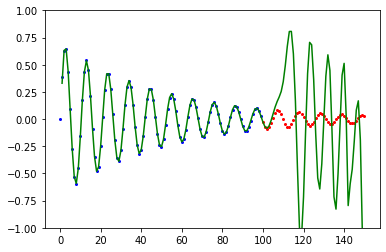

106400 3.379835068654412e-05 0.04225170717138985


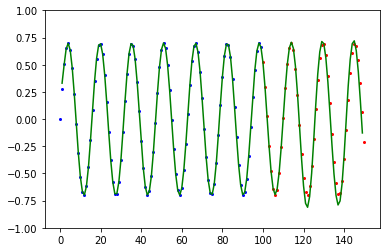

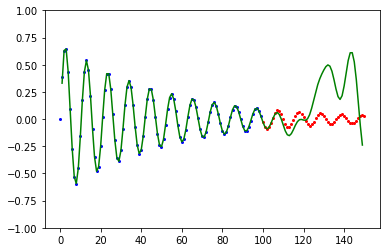

117300 3.3814884499782036e-05 4.461889015158246


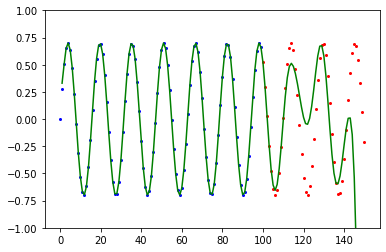

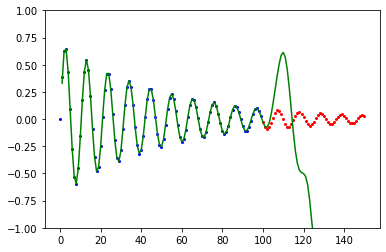

123300 3.378805459704037e-05 0.07849721846506819


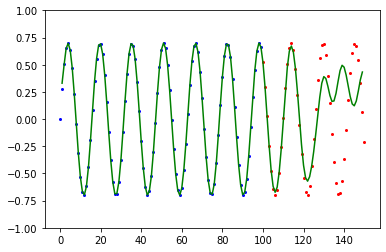

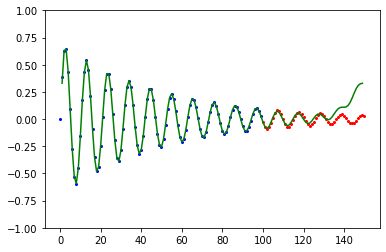

128500 3.333942466954562e-05 0.21395334437922622


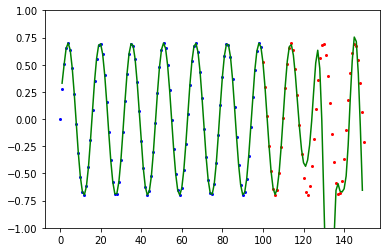

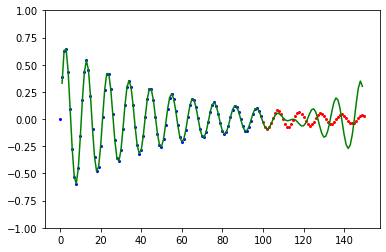

137700 3.309254355721586e-05 0.16766947018703107


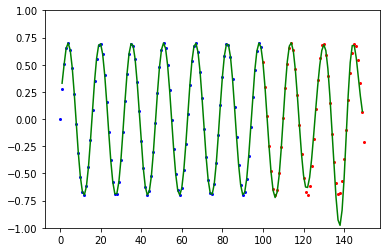

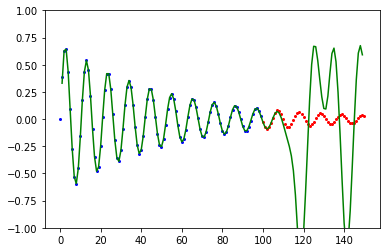

143000 3.344854681826957e-05 0.05547939479064446


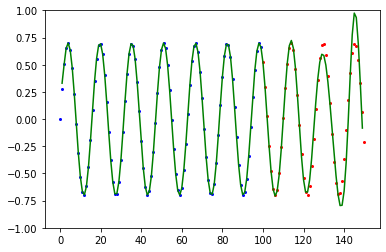

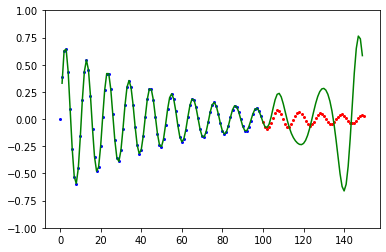

149100 3.4686572459291924e-05 0.08981155415679615


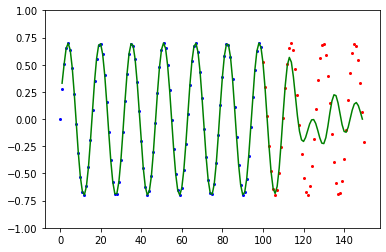

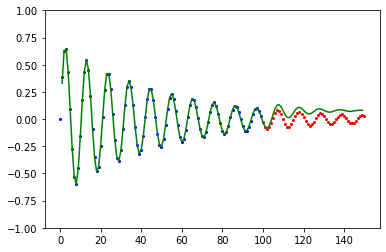

157300 3.607032878873264e-05 0.08760518150565126


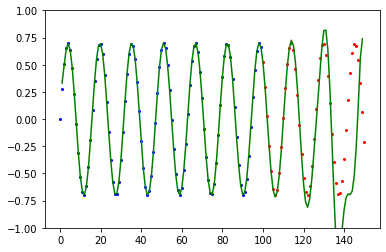

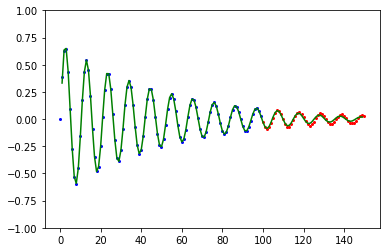

164100 3.649939268252912e-05 3.1285549498124205


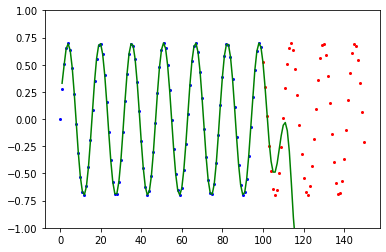

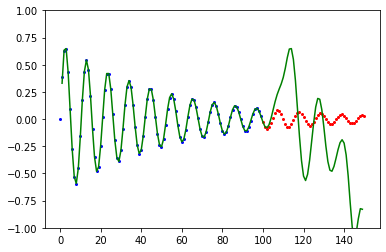

171100 3.330327393160999e-05 0.43776179570001655


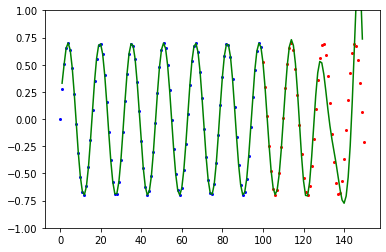

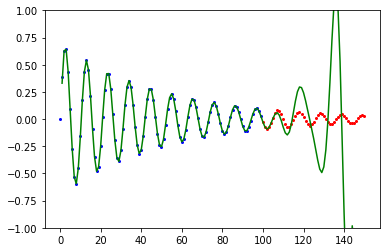

179600 3.440497588619435e-05 4.166292964167065


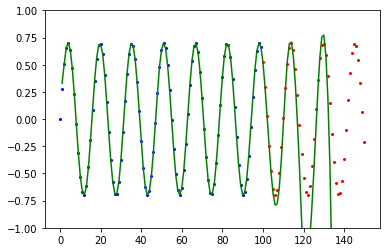

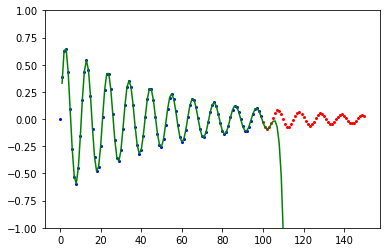

184300 3.356793486542907e-05 0.07763489093403987


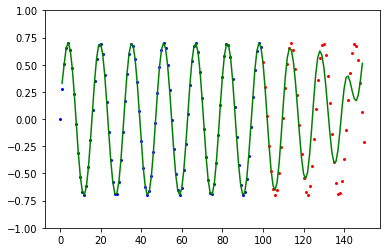

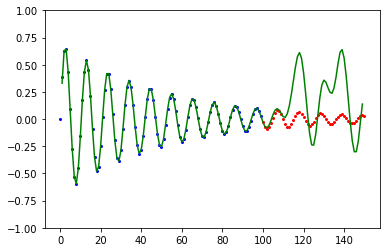

190300 3.432695833920342e-05 0.12518154459490624


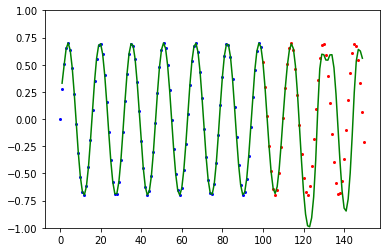

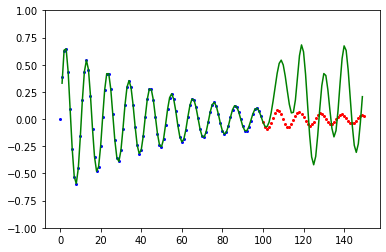

198200 3.340305688930797e-05 1.7044069119597163


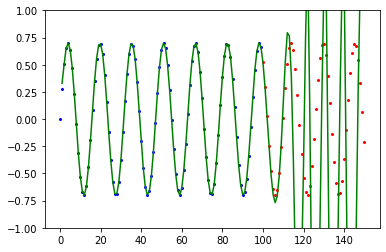

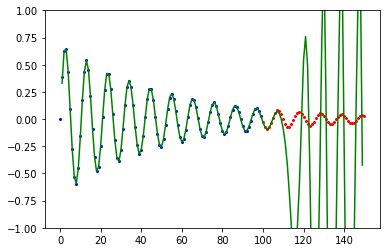

203500 3.368208365139274e-05 0.02143822266462871


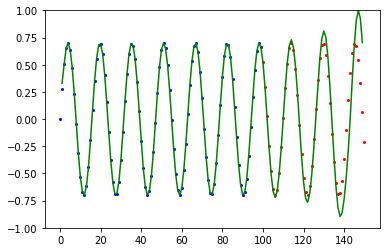

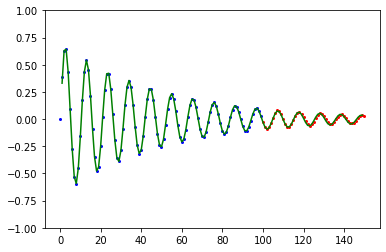

209500 3.623482272302667e-05 0.3914829023091506


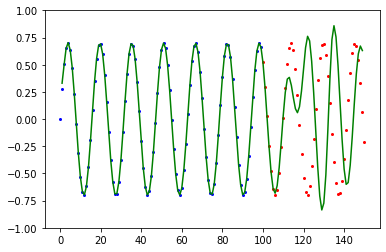

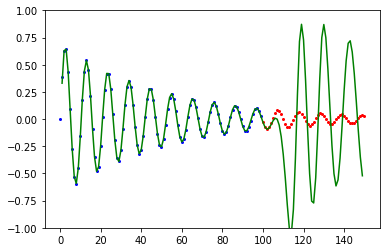

216100 3.320542446603405e-05 0.14909261913931052


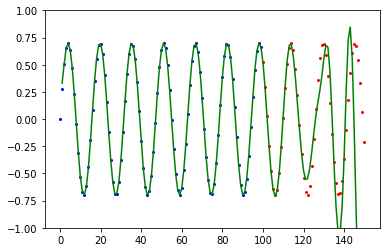

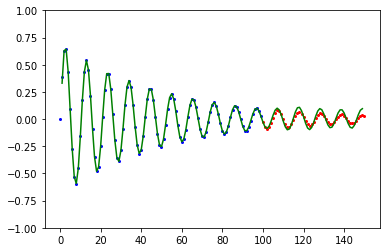

220700 3.3366426422020265e-05 0.14420807286615922


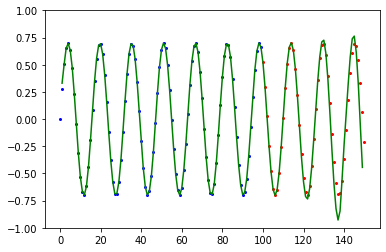

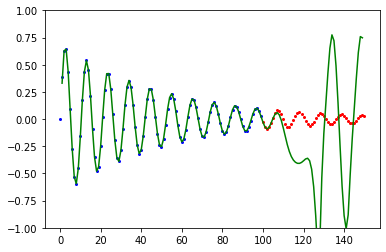

229100 3.303207426388903e-05 0.0008286727611273894


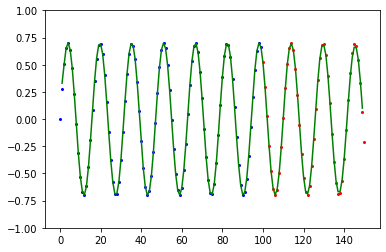

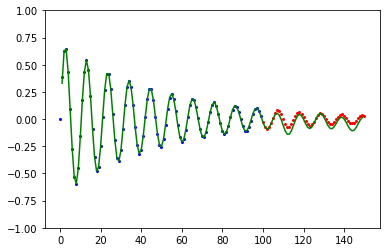

236200 3.3769746906043905e-05 0.9216627690645439


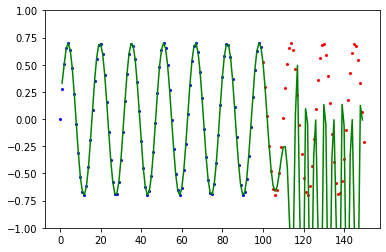

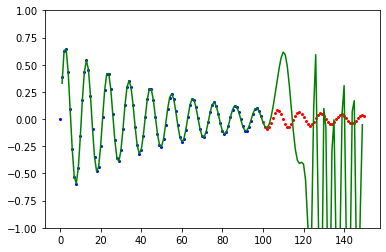

245700 3.4150769194116716e-05 0.09057154759775006


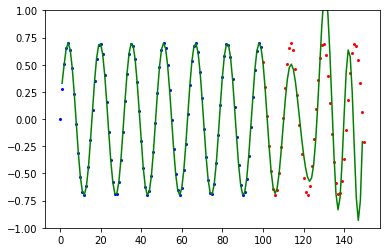

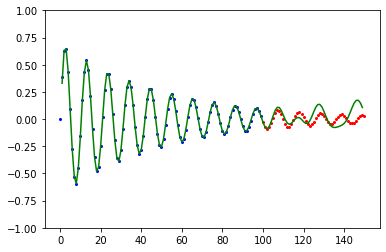

253600 3.388347671705534e-05 0.0035227174124360626


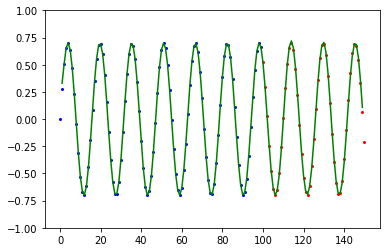

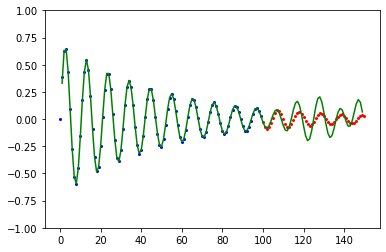

262500 3.312227501955118e-05 0.13069487894630943


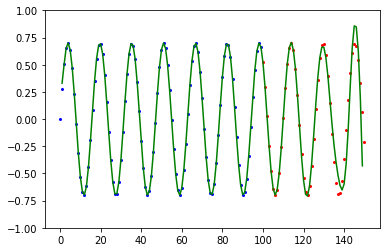

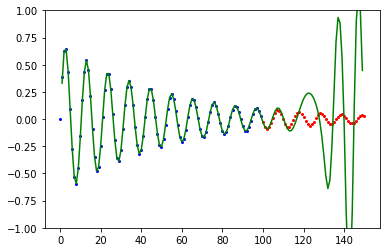

267100 3.4753327813518136e-05 0.004740767040763524


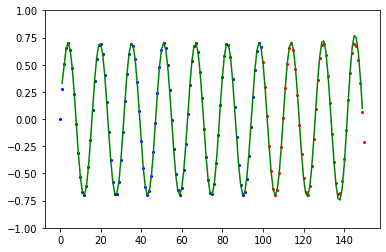

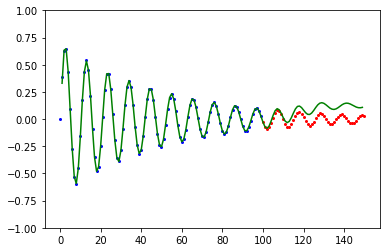

270400 3.3706534835665595e-05 0.4455320809596755


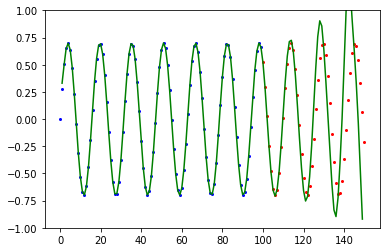

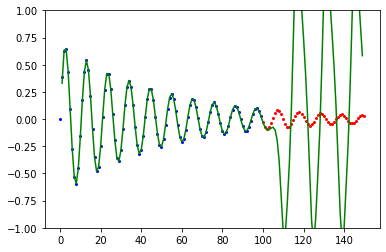

283000 3.33589396911183e-05 0.14452242010852567


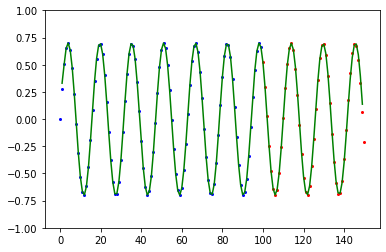

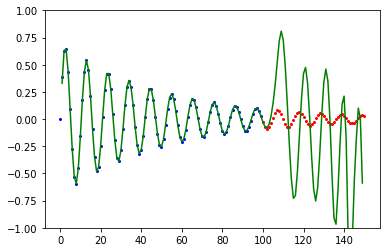

289800 3.330503415540534e-05 0.0011996576469214414


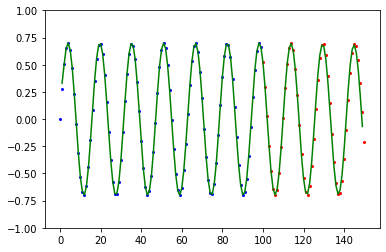

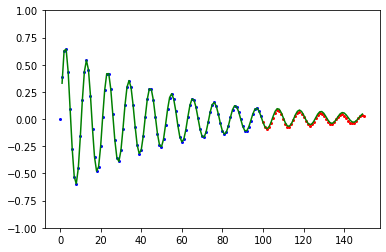

296200 3.3321690354710804e-05 0.06999453893935174


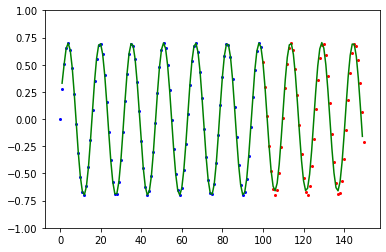

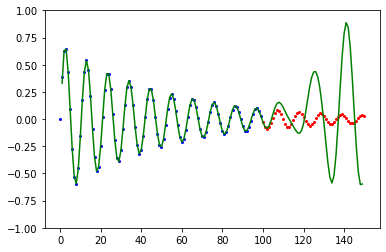

301200 3.31305486835759e-05 0.7451222063441805


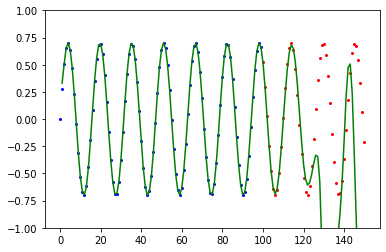

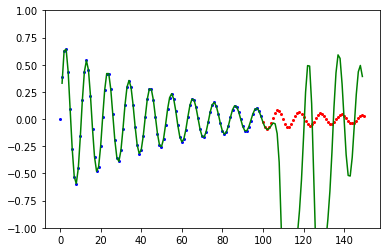

306900 3.462514974672652e-05 0.6087831797251017


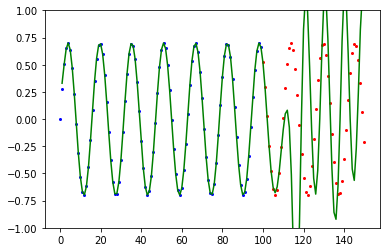

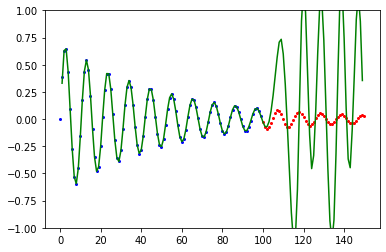

311600 3.3864509991725066e-05 0.22294427029086158


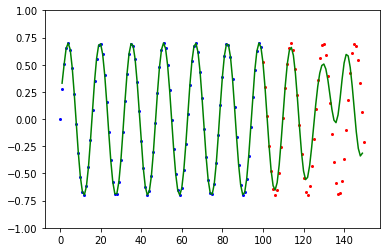

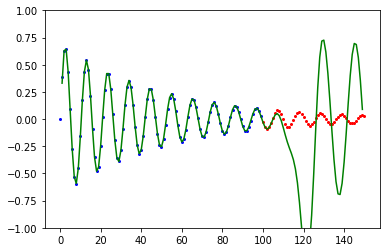

318200 3.335938907606704e-05 0.3138084992327014


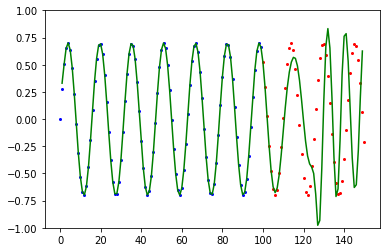

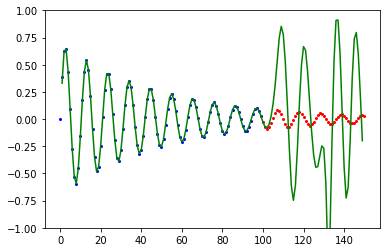

329200 4.220799514367999e-05 0.07661637094646283


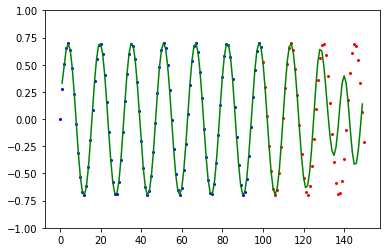

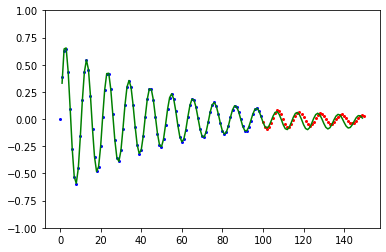

335500 3.311020136319969e-05 0.4228275140838309


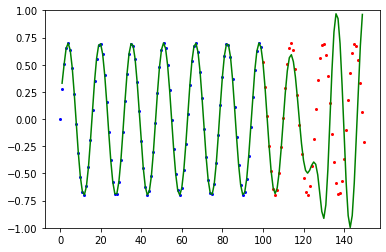

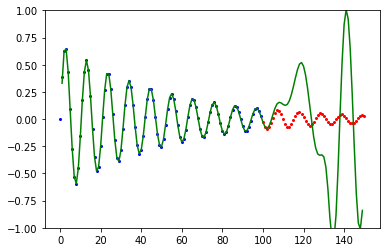

340600 0.002887547407588039 0.15961891283531932


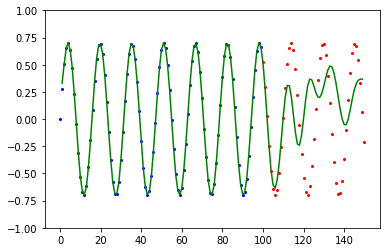

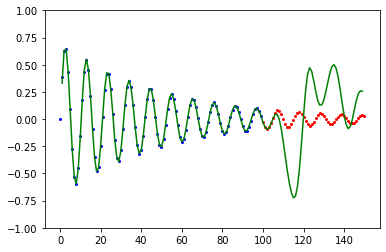

In [33]:
print('best:', test_result[min_idx][0:3])
for pak in test_result:
    i, i_loss, t_loss, _, ys = pak
    print(i, i_loss, t_loss)
    for idx in [0, 1]:
        plt.scatter(range(len(true1[idx])), true1[idx], c='b', s=4)
        plt.scatter(jnp.array(range(len(true2[idx])))+len(true1[idx]), true2[idx], c='r', s=4)
        plt.plot(jnp.array(range(len(ys[idx])))+1, ys[idx], c='g')
        plt.ylim(-1,1)
        plt.show()

In [34]:
sum([_[2] for _ in test_result])/len(test_result)

Array(0.48561616, dtype=float64)

In [35]:
len(test_result)

50